# Agent vs. Customer Utterance Classifier - Taskmaster (TM-1 & TM-2)

This notebook builds a binary text classifier that predicts whether a single
utterance from a task-oriented dialogue was spoken by the **agent**
(`ASSISTANT`) or the **customer** (`USER`).

Data source: [google-research-datasets/Taskmaster](https://github.com/google-research-datasets/Taskmaster)

We use:
- **TM-1** (2019): `self-dialogs.json` + `woz-dialogs.json`
- **TM-2** (2020): all domain files under `TM-2-2020/data/` (flights, hotels, movies, music, restaurant-search, sports, food-ordering)

## Pipeline
1. Download the dataset (shallow git clone)
2. Parse every conversation into `(text, speaker)` pairs
3. Explore the raw data visually
4. Clean & deduplicate, then split into train/test
5. Vectorize text with TF-IDF
6. Train several classical ML models
7. Compare models visually (bar chart, confusion matrices, ROC curves)
8. Verify models on a hand-written sanity-check set and inspect real errors

## 1. Setup & Data Download

In [1]:
import os, json, glob, time, subprocess, random
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

DATA_DIR = "Taskmaster"
PALETTE = ["#4C72B0", "#DD8452", "#55A868", "#C44E52", "#8172B2", "#CCB974"]  # simple, non-viridis colors
RANDOM_SEED = 98785601

# Apply random seed globally
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

if not os.path.isdir(DATA_DIR):
    subprocess.run(
        ["git", "clone", "--depth", "1",
         "https://github.com/google-research-datasets/Taskmaster.git", DATA_DIR],
        check=True,
    )

print(f"Data directory ready: {DATA_DIR}/")

Data directory ready: Taskmaster/


In [2]:
%pip install -q mlflow
import mlflow
import os

# Configure MLflow tracking server connection using provided credentials
os.environ["MLFLOW_TRACKING_URI"] = "https://dagshub.com/jalalqassas/vocalMind.mlflow"
os.environ["MLFLOW_TRACKING_USERNAME"] = "jalalqassas"
os.environ["MLFLOW_TRACKING_PASSWORD"] = "56fa62fc8fb1ef39d3c67021e2da18c8cb521100"

mlflow.set_tracking_uri(os.environ["MLFLOW_TRACKING_URI"])
mlflow.set_experiment("customer-agent-classification")

def log_to_mlflow(run_name, model_name, vectorizer_name, vectorizer, metrics, model=None):
    """
    Log training details, parameters, metrics, and the model artifact to MLflow.
    """
    try:
        # End any active runs to prevent nesting errors
        if mlflow.active_run():
            mlflow.end_run()
            
        with mlflow.start_run(run_name=run_name):
            # Log feature extraction parameters
            mlflow.log_param("vectorizer_type", vectorizer_name)
            if vectorizer:
                mlflow.log_param("ngram_range", str(vectorizer.ngram_range))
                mlflow.log_param("max_features", vectorizer.max_features)
                mlflow.log_param("min_df", vectorizer.min_df)
                mlflow.log_param("sublinear_tf", getattr(vectorizer, "sublinear_tf", None))
            
            # Log model details
            mlflow.log_param("model_name", model_name)
            if model:
                mlflow.log_param("model_class", model.__class__.__name__)
                try:
                    params = model.get_params()
                    simple_params = {
                        k: v for k, v in params.items()
                        if v is None or isinstance(v, (int, float, str, bool))
                    }
                    mlflow.log_params(simple_params)
                except AttributeError:
                    pass
                
                # Log model artifact binary
                try:
                    mlflow.sklearn.log_model(model, "model")
                except Exception as me:
                    print(f"Warning: Failed to log model artifact: {me}")
            
            # Log metrics
            mlflow.log_metrics(metrics)
            print(f"Successfully logged {run_name} to MLflow.")
    except Exception as e:
        print(f"Warning: Failed to log {run_name} to MLflow: {e}")

Note: you may need to restart the kernel to use updated packages.


## 2. Load & Parse Conversations

In [3]:
def load_taskmaster(root=DATA_DIR):
    '''Flatten every TM-1 / TM-2 conversation file into (text, speaker, dataset) rows.'''
    files = {
        "TM-1": [
            f"{root}/TM-1-2019/self-dialogs.json",
            f"{root}/TM-1-2019/woz-dialogs.json",
        ],
        "TM-2": sorted(glob.glob(f"{root}/TM-2-2020/data/*.json")),
    }

    records = [
        (utt.get("text", ""), utt.get("speaker"), dataset)
        for dataset, paths in files.items()
        for path in paths
        for conv in json.load(open(path, encoding="utf-8"))
        for utt in conv.get("utterances", [])
    ]
    return pd.DataFrame(records, columns=["text", "speaker", "dataset"])

raw_df = load_taskmaster()

# keep only well-formed USER / ASSISTANT turns with non-empty text
raw_df["text"] = raw_df["text"].str.strip()
raw_df = raw_df[raw_df["speaker"].isin(["USER", "ASSISTANT"]) & (raw_df["text"].str.len() > 0)]
raw_df = raw_df.reset_index(drop=True)

print(f"Loaded {len(raw_df):,} utterances")
raw_df.head()


Loaded 644,812 utterances


,text,speaker,dataset
0,"Hi, I'm looking to book a table for Korean fod.",USER,TM-1
1,"Ok, what area are you thinking about?",ASSISTANT,TM-1
2,"Somewhere in Southern NYC, maybe the East Vill...",USER,TM-1
3,"Ok, great. There's Thursday Kitchen, it has g...",ASSISTANT,TM-1
4,That's great. So I need a table for tonight at...,USER,TM-1


## 3. Exploratory Data Analysis

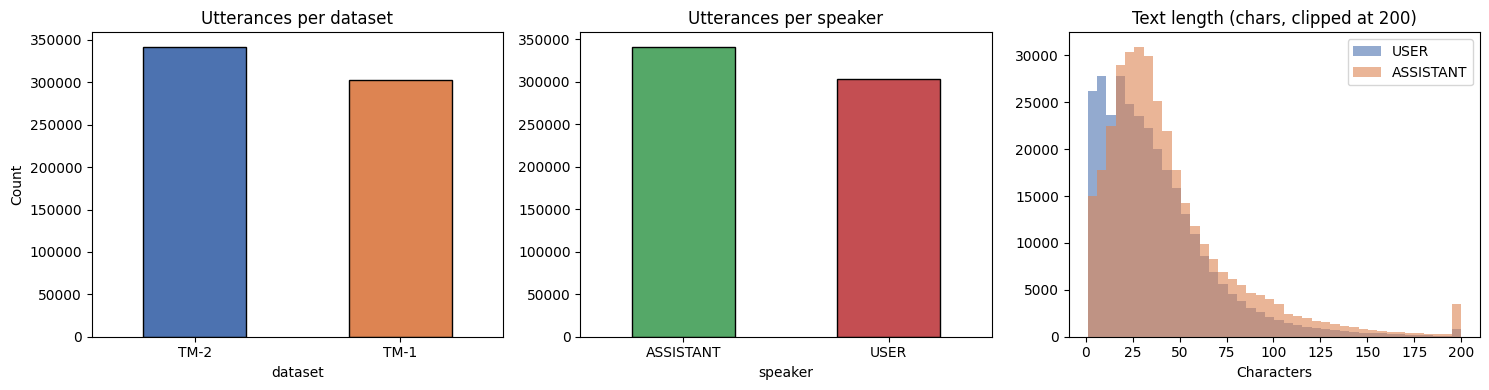

In [4]:

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

raw_df["dataset"].value_counts().plot(
    kind="bar", ax=axes[0], color=PALETTE[:2], edgecolor="black"
)
axes[0].set_title("Utterances per dataset")
axes[0].set_ylabel("Count")
axes[0].tick_params(axis="x", rotation=0)

raw_df["speaker"].value_counts().plot(
    kind="bar", ax=axes[1], color=PALETTE[2:4], edgecolor="black"
)
axes[1].set_title("Utterances per speaker")
axes[1].tick_params(axis="x", rotation=0)

for speaker, color in zip(["USER", "ASSISTANT"], PALETTE[:2]):
    lengths = raw_df.loc[raw_df["speaker"] == speaker, "text"].str.len()
    axes[2].hist(lengths.clip(upper=200), bins=40, alpha=0.6, label=speaker, color=color)
axes[2].set_title("Text length (chars, clipped at 200)")
axes[2].set_xlabel("Characters")
axes[2].legend()

plt.tight_layout()
plt.show()



## 4. Cleaning & Label Preparation

- Map `ASSISTANT -> agent (1)` and `USER -> customer (0)`.
- Drop very short (< 2 characters) utterances.
- Drop exact-duplicate `(text, label)` rows (mostly generic greetings repeated
  across many conversations) to avoid one phrase dominating the dataset and
  leaking identically between train and test.
- Drop texts that appear under **both** labels (ambiguous, e.g. "Yes.",
  "Okay.") since they provide no usable signal for a text-only classifier.


Clean dataset: 407,303 utterances


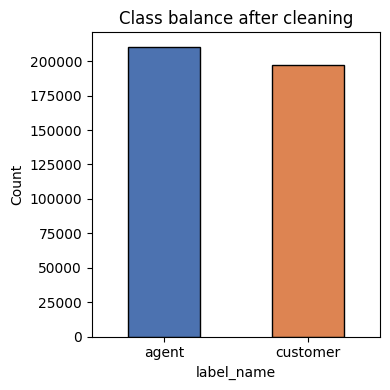

In [5]:

df = raw_df[raw_df["text"].str.len() >= 2].copy()
df["label"] = (df["speaker"] == "ASSISTANT").astype(int)   # 1 = agent, 0 = customer
df["label_name"] = df["label"].map({1: "agent", 0: "customer"})

df = df.drop_duplicates(subset=["text", "label"])

ambiguous = df.groupby("text")["label"].nunique().loc[lambda s: s > 1].index
df = df[~df["text"].isin(ambiguous)].reset_index(drop=True)

print(f"Clean dataset: {len(df):,} utterances")

df["label_name"].value_counts().plot(
    kind="bar", color=PALETTE[:2], edgecolor="black", figsize=(4, 4)
)
plt.title("Class balance after cleaning")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


## 5. Train / Test Split

In [6]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    df["text"], df["label"],
    test_size=0.2, random_state=RANDOM_SEED, stratify=df["label"],
)

print(f"Train: {len(X_train):,}  |  Test: {len(X_test):,}")

Train: 325,842  |  Test: 81,461


## 6. Feature Extraction - TF-IDF

A single TF-IDF vectorizer (word uni- & bi-grams) is fit on the training data
and reused for every model so that results are directly comparable.

In [7]:

from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(ngram_range=(1, 2), min_df=3, max_features=50_000, sublinear_tf=True)

X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

print(f"TF-IDF matrix shape: {X_train_tfidf.shape}")


TF-IDF matrix shape: (325842, 50000)


## 7. Train Multiple Models

| Model | Notes |
|---|---|
| Logistic Regression | strong linear baseline, `liblinear` solver |
| Linear SVM (`LinearSVC`) | margin-based linear classifier, often best for sparse TF-IDF |
| Multinomial Naive Bayes | fast probabilistic baseline for word counts |
| SGD Classifier (log loss) | linear model trained with stochastic gradient descent, scales well |
| Random Forest | non-linear ensemble baseline |
<!-- | Neural Network | Multi-layer Perceptron (MLP) classifier | -->

In [8]:
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.svm import LinearSVC, SVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier

def create_model(model_name, params, random_seed=RANDOM_SEED):
    """Factory function to instantiate models with mapped hyperparameters."""
    kwargs = {}
    for k, v in params.items():
        if k in ["max_depth", "n_estimators", "degree", "max_iter"]:
            kwargs[k] = int(round(v))
        else:
            kwargs[k] = float(v)
            
    if model_name == "Logistic Regression":
        return LogisticRegression(max_iter=1000, solver="liblinear", random_state=random_seed, **kwargs)
    elif model_name == "Linear SVM":
        return LinearSVC(random_state=random_seed, **kwargs)
    elif model_name == "Multinomial Naive Bayes":
        return MultinomialNB(**kwargs)
    elif model_name == "SGD (log loss)":
        return SGDClassifier(loss="log_loss", random_state=random_seed, **kwargs)
    elif model_name == "Random Forest":
        return RandomForestClassifier(n_jobs=-1, random_state=random_seed, **kwargs)
    elif model_name == "Neural Network":
        return MLPClassifier(hidden_layer_sizes=(64,), max_iter=10, early_stopping=True, random_state=random_seed, **kwargs)
    elif model_name == "RBF SVM":
        max_iter = kwargs.pop("max_iter", 500)
        return SVC(kernel="rbf", max_iter=max_iter, random_state=random_seed, **kwargs)
    elif model_name == "Multinomial SVM":
        max_iter = kwargs.pop("max_iter", 500)
        return SVC(kernel="poly", max_iter=max_iter, random_state=random_seed, **kwargs)
    else:
        raise ValueError(f"Unknown model: {model_name}")

models = {
    "Logistic Regression": create_model("Logistic Regression", {}),
    "Linear SVM": create_model("Linear SVM", {}),
    "Multinomial Naive Bayes": create_model("Multinomial Naive Bayes", {}),
    "SGD (log loss)": create_model("SGD (log loss)", {}),
    "Random Forest": create_model("Random Forest", {"n_estimators": 100, "max_depth": 30}),
    "Neural Network": create_model("Neural Network", {}),
    "RBF SVM": create_model("RBF SVM", {"max_iter": 1000}),
    "Multinomial SVM": create_model("Multinomial SVM", {"degree": 3, "max_iter": 1000})
}

trained = {}
for name, model in models.items():
    start = time.time()
    model.fit(X_train_tfidf, y_train)
    trained[name] = model
    print(f"{name:<25} trained in {time.time() - start:6.1f}s")

Logistic Regression       trained in    5.3s
Linear SVM                trained in    8.4s
Multinomial Naive Bayes   trained in    0.1s
SGD (log loss)            trained in    1.1s
Random Forest             trained in   22.3s


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (10) reached and the optimization hasn't converged yet.
  warnings.warn(


Neural Network            trained in 1158.4s


/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=1000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(


RBF SVM                   trained in   50.1s
Multinomial SVM           trained in   53.3s


/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=1000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(


## 8. Evaluate & Compare Models

In [9]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

def get_scores(model, X):
    '''Continuous score for ROC-AUC: predict_proba if available, else decision_function (LinearSVC).'''
    if hasattr(model, "predict_proba"):
        return model.predict_proba(X)[:, 1]
    return model.decision_function(X)

predictions, scores, results = {}, {}, []
for name, model in trained.items():
    predictions[name] = model.predict(X_test_tfidf)
    scores[name] = get_scores(model, X_test_tfidf)
    
    acc = accuracy_score(y_test, predictions[name])
    prec = precision_score(y_test, predictions[name])
    rec = recall_score(y_test, predictions[name])
    f1 = f1_score(y_test, predictions[name])
    auc = roc_auc_score(y_test, scores[name])
    
    results.append({
        "Model": name,
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "F1": f1,
        "ROC-AUC": auc,
    })
    
    # Log results to DagsHub MLflow server
    log_to_mlflow(
        run_name=f"{name} (Word TF-IDF)",
        model_name=name,
        vectorizer_name="word_tfidf",
        vectorizer=vectorizer,
        metrics={
            "accuracy": acc,
            "precision": prec,
            "recall": rec,
            "f1": f1,
            "roc_auc": auc
        },
        model=model
    )

results_df = pd.DataFrame(results).set_index("Model").sort_values("F1", ascending=False)
results_df.round(4)

2026/06/16 03:50:03 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/06/16 03:50:04 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Successfully logged Logistic Regression (Word TF-IDF) to MLflow.
🏃 View run Logistic Regression (Word TF-IDF) at: https://dagshub.com/jalalqassas/vocalMind.mlflow/#/experiments/0/runs/85c2377290ee459a8232c8136d0721c5
🧪 View experiment at: https://dagshub.com/jalalqassas/vocalMind.mlflow/#/experiments/0


2026/06/16 03:50:24 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/06/16 03:50:28 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Successfully logged Linear SVM (Word TF-IDF) to MLflow.
🏃 View run Linear SVM (Word TF-IDF) at: https://dagshub.com/jalalqassas/vocalMind.mlflow/#/experiments/0/runs/e3187832259e4b99827932f2aa0445f1
🧪 View experiment at: https://dagshub.com/jalalqassas/vocalMind.mlflow/#/experiments/0


2026/06/16 03:51:04 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/06/16 03:51:08 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


...

2026/06/16 03:54:04 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/06/16 03:54:05 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Successfully logged RBF SVM (Word TF-IDF) to MLflow.
🏃 View run RBF SVM (Word TF-IDF) at: https://dagshub.com/jalalqassas/vocalMind.mlflow/#/experiments/0/runs/f7ed92621eb8402984f5afc3bbe41f54
🧪 View experiment at: https://dagshub.com/jalalqassas/vocalMind.mlflow/#/experiments/0


2026/06/16 03:54:36 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/06/16 03:54:40 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Successfully logged Multinomial SVM (Word TF-IDF) to MLflow.
🏃 View run Multinomial SVM (Word TF-IDF) at: https://dagshub.com/jalalqassas/vocalMind.mlflow/#/experiments/0/runs/9aa5deafe93e462ea261f5d8c74d2393
🧪 View experiment at: https://dagshub.com/jalalqassas/vocalMind.mlflow/#/experiments/0


,Accuracy,Precision,Recall,F1,ROC-AUC
Model,,,,,
Linear SVM,0.9245,0.9314,0.9216,0.9265,0.9771
Neural Network,0.9238,0.9327,0.9187,0.9257,0.9762
Logistic Regression,0.9222,0.9274,0.9216,0.9245,0.9755
Multinomial Naive Bayes,0.8925,0.8914,0.9017,0.8965,0.9623
SGD (log loss),0.8877,0.8955,0.8861,0.8908,0.9538
Random Forest,0.8622,0.8768,0.8531,0.8648,0.9439
RBF SVM,0.6635,0.7124,0.5846,0.6422,0.7336
Multinomial SVM,0.5027,0.9296,0.0405,0.0776,0.7262


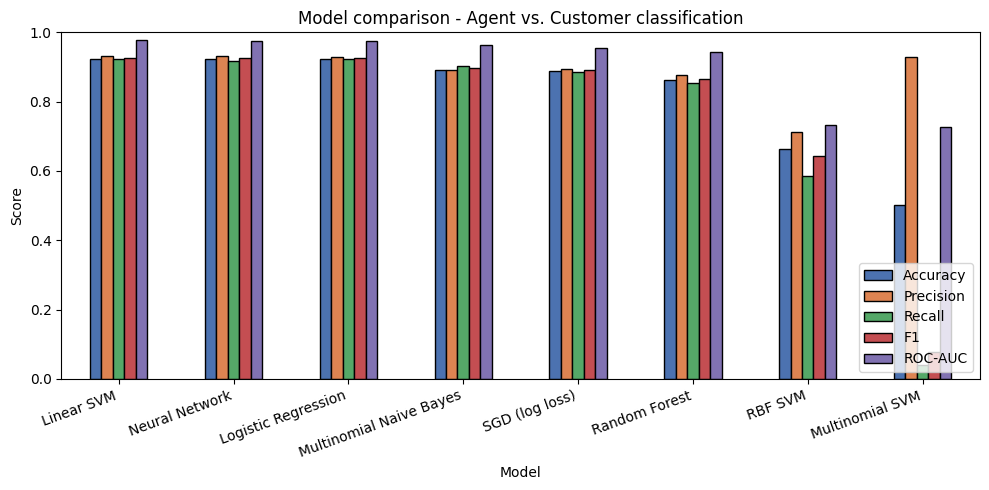

In [10]:
ax = results_df[["Accuracy", "Precision", "Recall", "F1", "ROC-AUC"]].plot(
    kind="bar", figsize=(10, 5), ylim=(0, 1), color=PALETTE, edgecolor="black"
)
ax.set_title("Model comparison - Agent vs. Customer classification")
ax.set_ylabel("Score")
ax.legend(loc="lower right")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()

## 9. Confusion Matrices - Every Model

Visual check of error types (false agent / false customer) side by side.

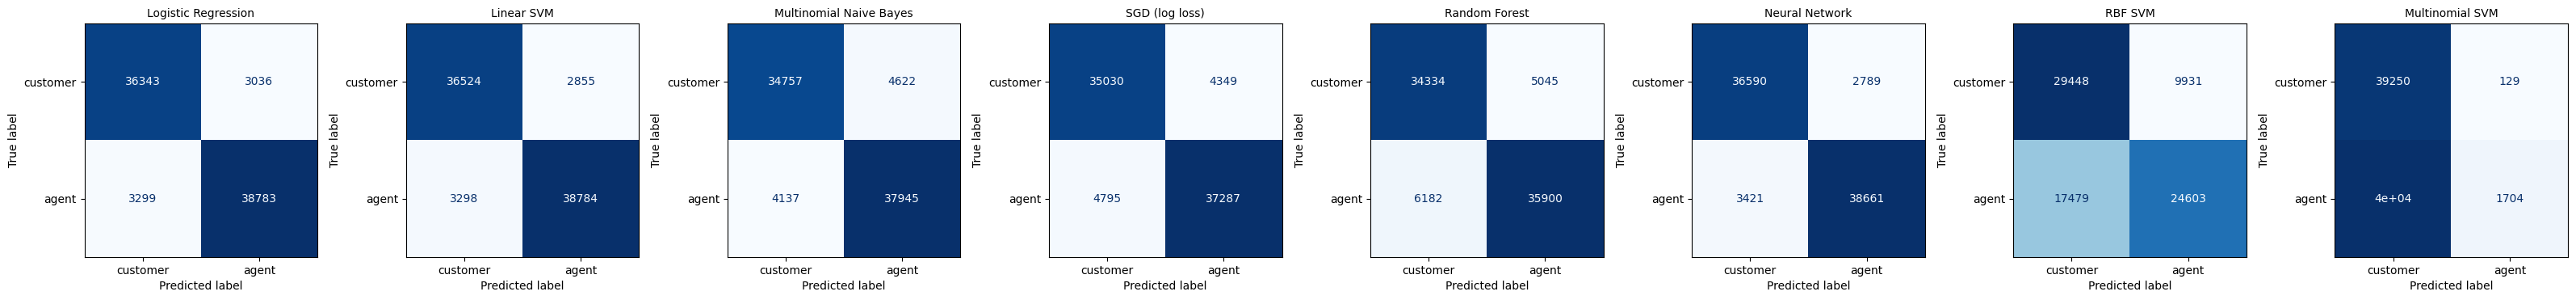

In [11]:

from sklearn.metrics import ConfusionMatrixDisplay

fig, axes = plt.subplots(1, len(trained), figsize=(4 * len(trained), 4))
for ax, (name, y_pred) in zip(axes, predictions.items()):
    ConfusionMatrixDisplay.from_predictions(
        y_test, y_pred, display_labels=["customer", "agent"],
        cmap="Blues", colorbar=False, ax=ax,
    )
    ax.set_title(name, fontsize=10)

plt.tight_layout()
plt.show()


## 10. ROC Curves - Every Model

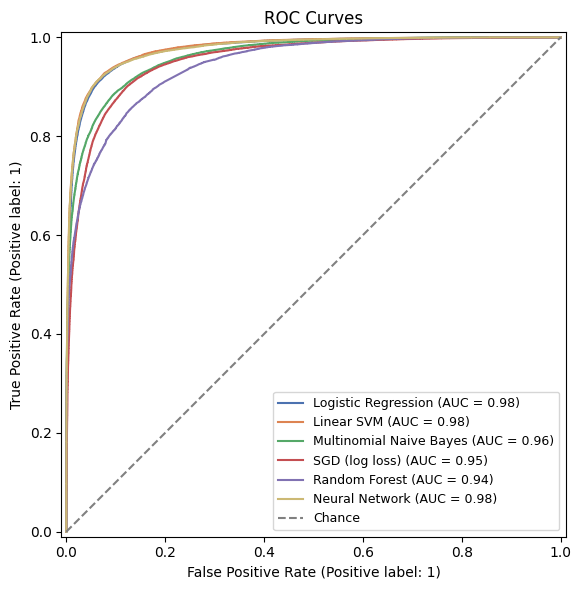

In [12]:
from sklearn.metrics import RocCurveDisplay

fig, ax = plt.subplots(figsize=(6, 6))
for (name, y_score), color in zip(scores.items(), PALETTE):
    RocCurveDisplay.from_predictions(y_test, y_score, name=name, ax=ax, color=color)

ax.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Chance")
ax.set_title("ROC Curves")
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

## 11. Verification - Hand-Written Sanity Check

The held-out test set comes from the same distribution as the training data,
so we also verify every model on a small set of **brand-new, hand-written
sentences** with known ground truth. This checks whether the models actually
learned the *agent vs. customer* concept, not just dataset-specific quirks.

In [13]:

sanity_set = [
    ("I'd like to book a flight to New York for next Friday.", "customer"),
    ("Can I get a refund for this order?", "customer"),
    ("What time does the restaurant close tonight?", "customer"),
    ("I want to cancel my reservation, please.", "customer"),
    ("Do you have a table for four available tonight?", "customer"),
    ("My flight got delayed, what should I do now?", "customer"),
    ("I need a hotel room for two nights in Boston.", "customer"),
    ("Could you check if there's a cheaper flight option?", "customer"),
    ("I'm looking for a pizza place near downtown.", "customer"),
    ("Sure, I can help you with that booking.", "agent"),
    ("Let me check the availability for you.", "agent"),
    ("Your reservation has been confirmed for 7 PM.", "agent"),
    ("I'm sorry, but that flight is fully booked.", "agent"),
    ("What date would you like to travel?", "agent"),
    ("I found a flight departing at 10 AM, would that work?", "agent"),
    ("Your order total comes to $45.99.", "agent"),
    ("I've successfully cancelled your reservation.", "agent"),
    ("Is there anything else I can help you with?", "agent"),
    ("Thank you for calling, have a great day!", "agent"),
]

sanity_texts = [t for t, _ in sanity_set]
sanity_true = [l for _, l in sanity_set]
sanity_tfidf = vectorizer.transform(sanity_texts)

sanity_table = pd.DataFrame({"text": sanity_texts, "true": sanity_true})
for name, model in trained.items():
    preds = model.predict(sanity_tfidf)
    sanity_table[name] = ["agent" if p else "customer" for p in preds]

sanity_acc = {name: (sanity_table[name] == sanity_table["true"]).mean() for name in trained}

print("Accuracy on hand-written sanity sentences:")
for name, acc in sorted(sanity_acc.items(), key=lambda x: -x[1]):
    print(f"  {name:<25} {acc:.2%}")

sanity_table


Accuracy on hand-written sanity sentences:
  Logistic Regression       100.00%
  Linear SVM                94.74%
  Random Forest             94.74%
  Neural Network            94.74%
  Multinomial Naive Bayes   89.47%
  SGD (log loss)            89.47%
  RBF SVM                   63.16%
  Multinomial SVM           52.63%


,text,true,Logistic Regression,Linear SVM,Multinomial Naive Bayes,SGD (log loss),Random Forest,Neural Network,RBF SVM,Multinomial SVM
0,I'd like to book a flight to New York for next...,customer,customer,customer,customer,customer,customer,customer,customer,customer
1,Can I get a refund for this order?,customer,customer,customer,agent,customer,customer,agent,customer,customer
2,What time does the restaurant close tonight?,customer,customer,customer,customer,customer,customer,customer,customer,customer
3,"I want to cancel my reservation, please.",customer,customer,customer,customer,customer,customer,customer,agent,customer
4,Do you have a table for four available tonight?,customer,customer,agent,agent,agent,agent,customer,agent,customer
5,"My flight got delayed, what should I do now?",customer,customer,customer,customer,customer,customer,customer,agent,customer
6,I need a hotel room for two nights in Boston.,customer,customer,customer,customer,customer,customer,customer,customer,customer
7,Could you check if there's a cheaper flight op...,customer,customer,customer,customer,customer,customer,customer,customer,customer
8,I'm looking for a pizza place near downtown.,customer,customer,customer,customer,customer,customer,customer,agent,customer
9,"Sure, I can help you with that booking.",agent,agent,agent,agent,agent,agent,agent,agent,customer


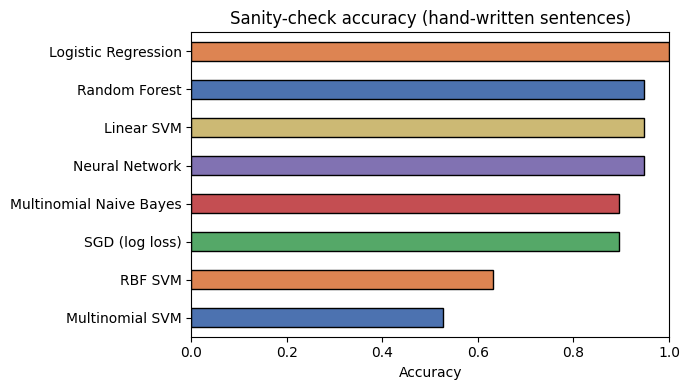

In [14]:
pd.Series(sanity_acc).sort_values().plot(
    kind="barh", figsize=(7, 4), color=PALETTE, edgecolor="black", xlim=(0, 1)
)
plt.title("Sanity-check accuracy (hand-written sentences)")
plt.xlabel("Accuracy")
plt.tight_layout()
plt.show()


## 12. Error Analysis - Best Model

Inspecting real misclassified test-set examples for the strongest model
(highest F1) to understand where it still struggles.

In [15]:
best_name = results_df["F1"].idxmax()
best_model = trained[best_name]
print(f"Best model: {best_name}\n")

errors = pd.DataFrame({
    "text": X_test.values,
    "true": y_test.map({1: "agent", 0: "customer"}).values,
    "predicted": pd.Series(predictions[best_name]).map({1: "agent", 0: "customer"}).values,
})
errors = errors[errors["true"] != errors["predicted"]]

print(f"Misclassified: {len(errors):,} / {len(X_test):,} test examples ({len(errors)/len(X_test):.2%})\n")
errors.sample(10, random_state=RANDOM_SEED)

Best model: Linear SVM

Misclassified: 6,153 / 81,461 test examples (7.55%)



,text,true,predicted
9779,The Starbucks on Peachtree Street?,agent,customer
38406,What about Fences?,customer,agent
38379,"Yes. If you get there by 6, you can order from...",agent,customer
20616,Because we've done this one together a couple ...,agent,customer
25194,Did you say in July 1st?,customer,agent
49877,Those are the options.,agent,customer
15670,yes and I can confirm with the kitchen staff,agent,customer
58786,That will be $8 please,agent,customer
77098,"Okay, I found a Regal Cinema in Garden Grove.",agent,customer
533,And with whip or not.,agent,customer


## 13. Try It Out

In [16]:
def predict_speaker(text, model=best_model, vec=vectorizer):
    return "agent" if model.predict(vec.transform([text]))[0] else "customer"

for ex in [
    "I'd like to book a table for two tonight at 7pm.",
    "Sure, I can help with that. What city are you in?",
    "Can you cancel my flight to Chicago?",
    "I'm sorry, but that flight is fully booked.",
]:
    print(f"[{predict_speaker(ex):>8}]  {ex}")


[customer]  I'd like to book a table for two tonight at 7pm.
[   agent]  Sure, I can help with that. What city are you in?
[customer]  Can you cancel my flight to Chicago?
[   agent]  I'm sorry, but that flight is fully booked.


## 13.5. Character n-gram Comparison

Train all models on character-level TF-IDF features (3-5 character n-grams) and compare performance side-by-side with the word-level baseline.

In [17]:
from sklearn.base import clone

char_vectorizer = TfidfVectorizer(analyzer='char_wb', ngram_range=(3, 5), min_df=3, max_features=50_000, sublinear_tf=True)
X_train_char = char_vectorizer.fit_transform(X_train)
X_test_char = char_vectorizer.transform(X_test)

char_results = []
for name, model in models.items():
    char_model = clone(model).fit(X_train_char, y_train)
    y_pred = char_model.predict(X_test_char)
    y_score = get_scores(char_model, X_test_char)
    
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_score)
    
    char_results.append({
        "Model": name,
        "Char_Accuracy": acc,
        "Char_F1": f1,
        "Char_ROC-AUC": auc
    })
    
    # Log results to DagsHub MLflow server
    log_to_mlflow(
        run_name=f"{name} (Char TF-IDF)",
        model_name=name,
        vectorizer_name="char_tfidf",
        vectorizer=char_vectorizer,
        metrics={
            "accuracy": acc,
            "f1": f1,
            "roc_auc": auc
        },
        model=char_model
    )

char_df = pd.DataFrame(char_results).set_index("Model")
comparison = results_df[["Accuracy", "F1", "ROC-AUC"]].join(char_df)
comparison.round(4)

2026/06/16 03:56:06 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/06/16 03:56:07 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Successfully logged Logistic Regression (Char TF-IDF) to MLflow.
🏃 View run Logistic Regression (Char TF-IDF) at: https://dagshub.com/jalalqassas/vocalMind.mlflow/#/experiments/0/runs/4cc204d6d7a345debff104e28807f0bd
🧪 View experiment at: https://dagshub.com/jalalqassas/vocalMind.mlflow/#/experiments/0


2026/06/16 03:57:03 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/06/16 03:57:11 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Successfully logged Linear SVM (Char TF-IDF) to MLflow.
🏃 View run Linear SVM (Char TF-IDF) at: https://dagshub.com/jalalqassas/vocalMind.mlflow/#/experiments/0/runs/dafd4ba0f3d94e7aa0436d45d4b420e9
🧪 View experiment at: https://dagshub.com/jalalqassas/vocalMind.mlflow/#/experiments/0


2026/06/16 03:57:43 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/06/16 03:57:47 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


...

/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=1000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
2026/06/16 04:21:17 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/06/16 04:21:18 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Successfully logged RBF SVM (Char TF-IDF) to MLflow.
🏃 View run RBF SVM (Char TF-IDF) at: https://dagshub.com/jalalqassas/vocalMind.mlflow/#/experiments/0/runs/711b842d78e74257bfb4e7b203a938ce
🧪 View experiment at: https://dagshub.com/jalalqassas/vocalMind.mlflow/#/experiments/0


/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=1000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
2026/06/16 04:28:02 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/06/16 04:28:03 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Successfully logged Multinomial SVM (Char TF-IDF) to MLflow.
🏃 View run Multinomial SVM (Char TF-IDF) at: https://dagshub.com/jalalqassas/vocalMind.mlflow/#/experiments/0/runs/5475d465b54e418f9e1bfc1056ec256f
🧪 View experiment at: https://dagshub.com/jalalqassas/vocalMind.mlflow/#/experiments/0


,Accuracy,F1,ROC-AUC,Char_Accuracy,Char_F1,Char_ROC-AUC
Model,,,,,,
Linear SVM,0.9245,0.9265,0.9771,0.8910,0.8940,0.9558
Neural Network,0.9238,0.9257,0.9762,0.9295,0.9318,0.9804
Logistic Regression,0.9222,0.9245,0.9755,0.8892,0.8925,0.9547
Multinomial Naive Bayes,0.8925,0.8965,0.9623,0.8229,0.8283,0.9060
SGD (log loss),0.8877,0.8908,0.9538,0.8615,0.8666,0.9344
Random Forest,0.8622,0.8648,0.9439,0.8805,0.8827,0.9540
RBF SVM,0.6635,0.6422,0.7336,0.6953,0.6686,0.7896
Multinomial SVM,0.5027,0.0776,0.7262,0.6832,0.7474,0.7907



Tuning hyperparameters for Logistic Regression...
  Running PSO...


2026/06/16 04:30:35 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/06/16 04:30:36 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


  Successfully logged Logistic Regression - PSO and its model artifact to MLflow.
🏃 View run Logistic Regression - PSO Tuning at: https://dagshub.com/jalalqassas/vocalMind.mlflow/#/experiments/0/runs/4e01024a00c44c5c974b0224fdb29922
🧪 View experiment at: https://dagshub.com/jalalqassas/vocalMind.mlflow/#/experiments/0
  Running GWO...


2026/06/16 04:33:00 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/06/16 04:33:01 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


  Successfully logged Logistic Regression - GWO and its model artifact to MLflow.
🏃 View run Logistic Regression - GWO Tuning at: https://dagshub.com/jalalqassas/vocalMind.mlflow/#/experiments/0/runs/c2dd1cadc63843f89b7cae2a466ec6b7
🧪 View experiment at: https://dagshub.com/jalalqassas/vocalMind.mlflow/#/experiments/0
  Running WOA...


...

/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=500).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=500).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=500).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=500).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=500).  Consider pre-

  Successfully logged Multinomial SVM - WOA and its model artifact to MLflow.
🏃 View run Multinomial SVM - WOA Tuning at: https://dagshub.com/jalalqassas/vocalMind.mlflow/#/experiments/0/runs/3e93e5f8de2240e48410e80fb4215119
🧪 View experiment at: https://dagshub.com/jalalqassas/vocalMind.mlflow/#/experiments/0
  Running ABC...


/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=500).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=500).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=500).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=500).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=500).  Consider pre-

  Successfully logged Multinomial SVM - ABC and its model artifact to MLflow.
🏃 View run Multinomial SVM - ABC Tuning at: https://dagshub.com/jalalqassas/vocalMind.mlflow/#/experiments/0/runs/674b28c0fb8649e48029f33bd64ef5f9
🧪 View experiment at: https://dagshub.com/jalalqassas/vocalMind.mlflow/#/experiments/0

Hyperparameter Tuning Results:
                  model method  accuracy        time                                             best_params
    Logistic Regression    PSO  0.927991  137.326780                                 {'C': 4.96563414479556}
    Logistic Regression    GWO  0.928100  121.310570                                {'C': 4.459452767422293}
    Logistic Regression    WOA  0.927991  138.492851                                {'C': 4.967166893492308}
    Logistic Regression    ABC  0.928119  223.200626                                {'C': 4.528832079097963}
             Linear SVM    PSO  0.928292  109.236489                               {'C': 0.3291934149476847}
  

/tmp/ipykernel_453/3470728091.py:345: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax2.set_xticklabels(ax2.get_xticklabels(), rotation=15, ha='right')


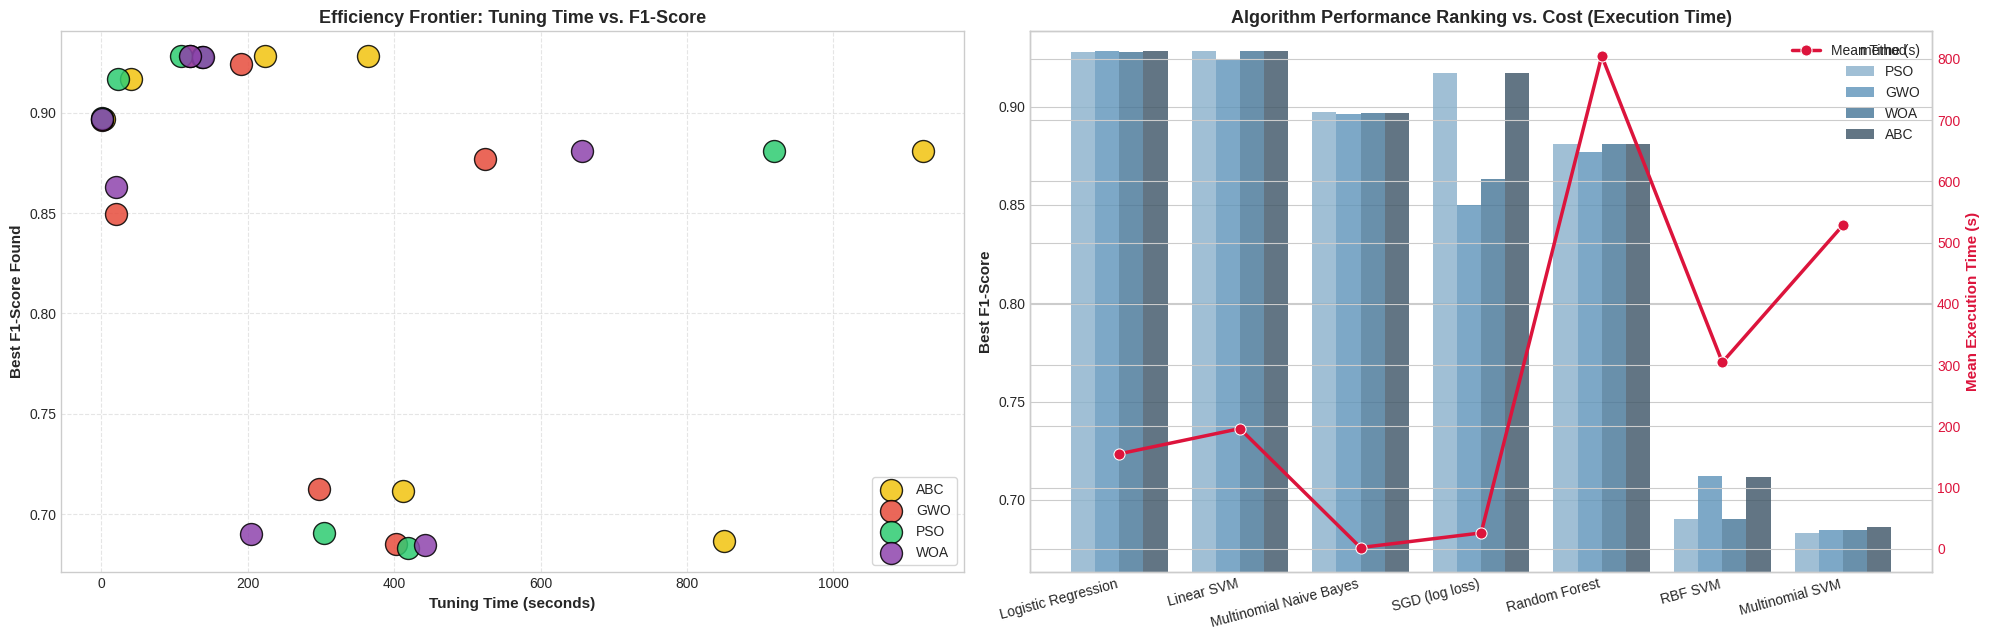

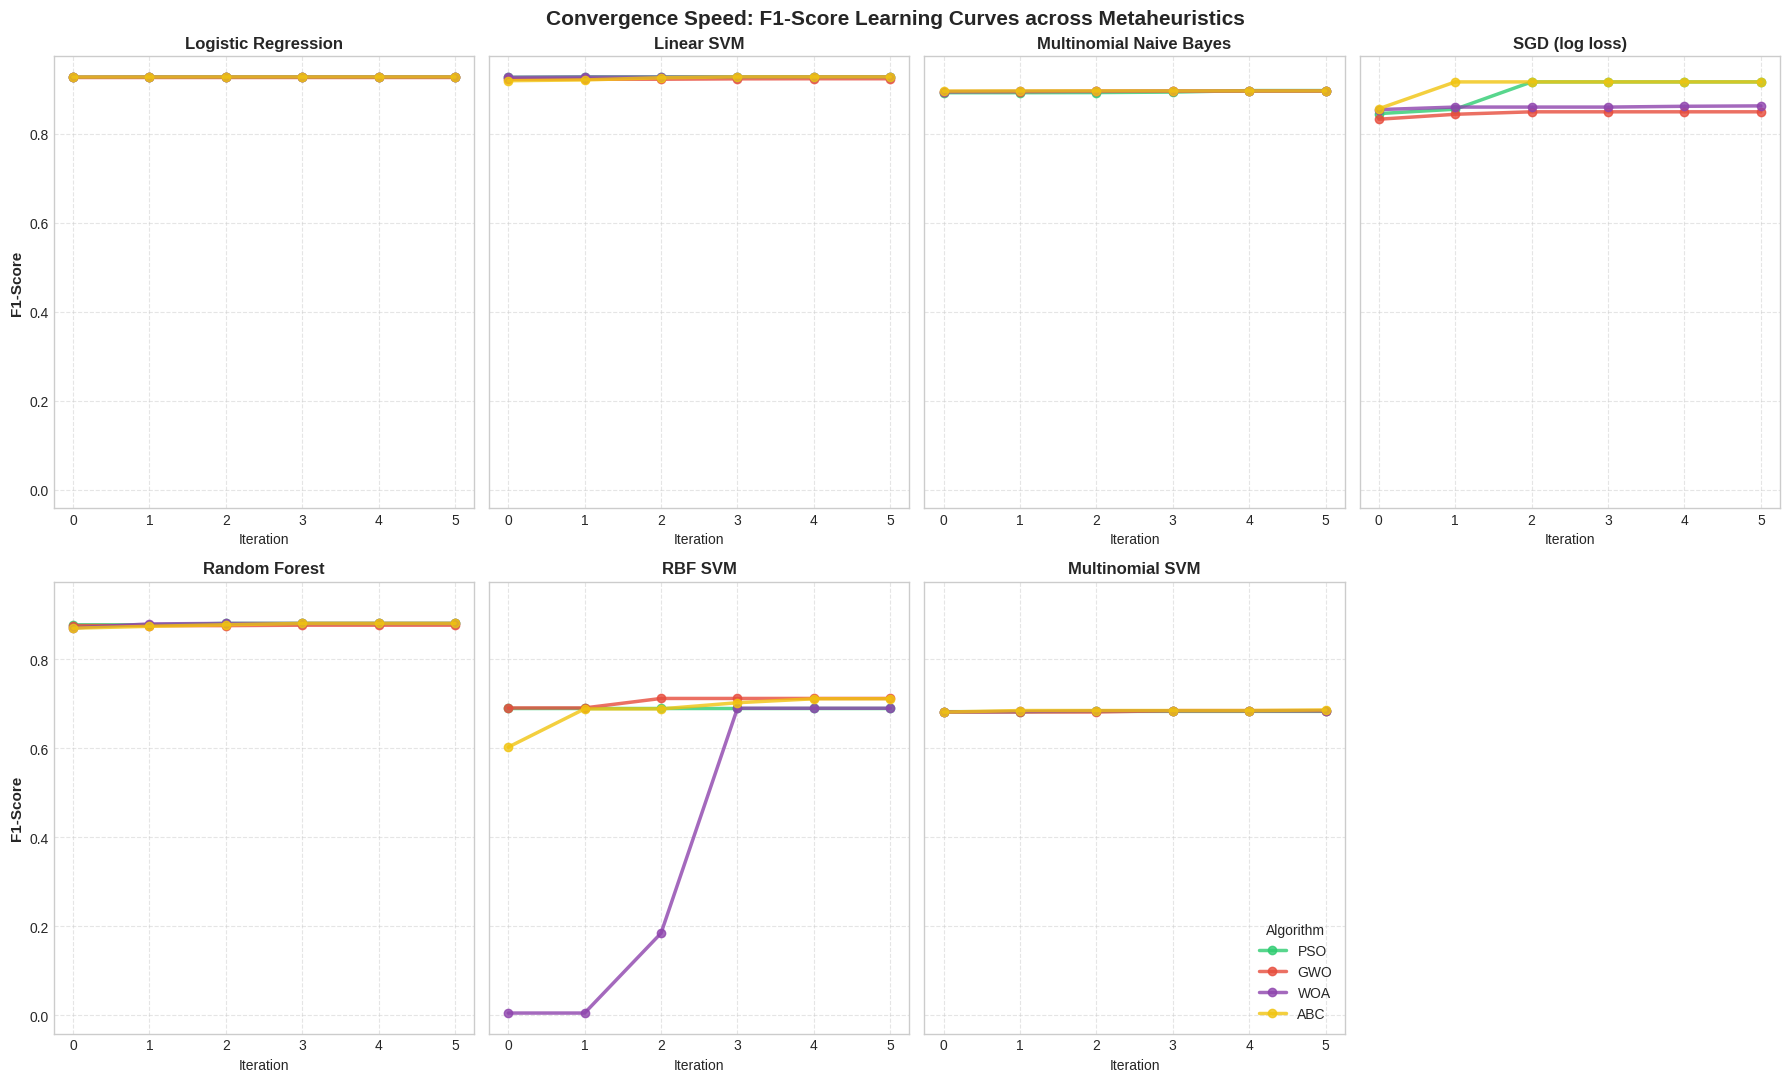

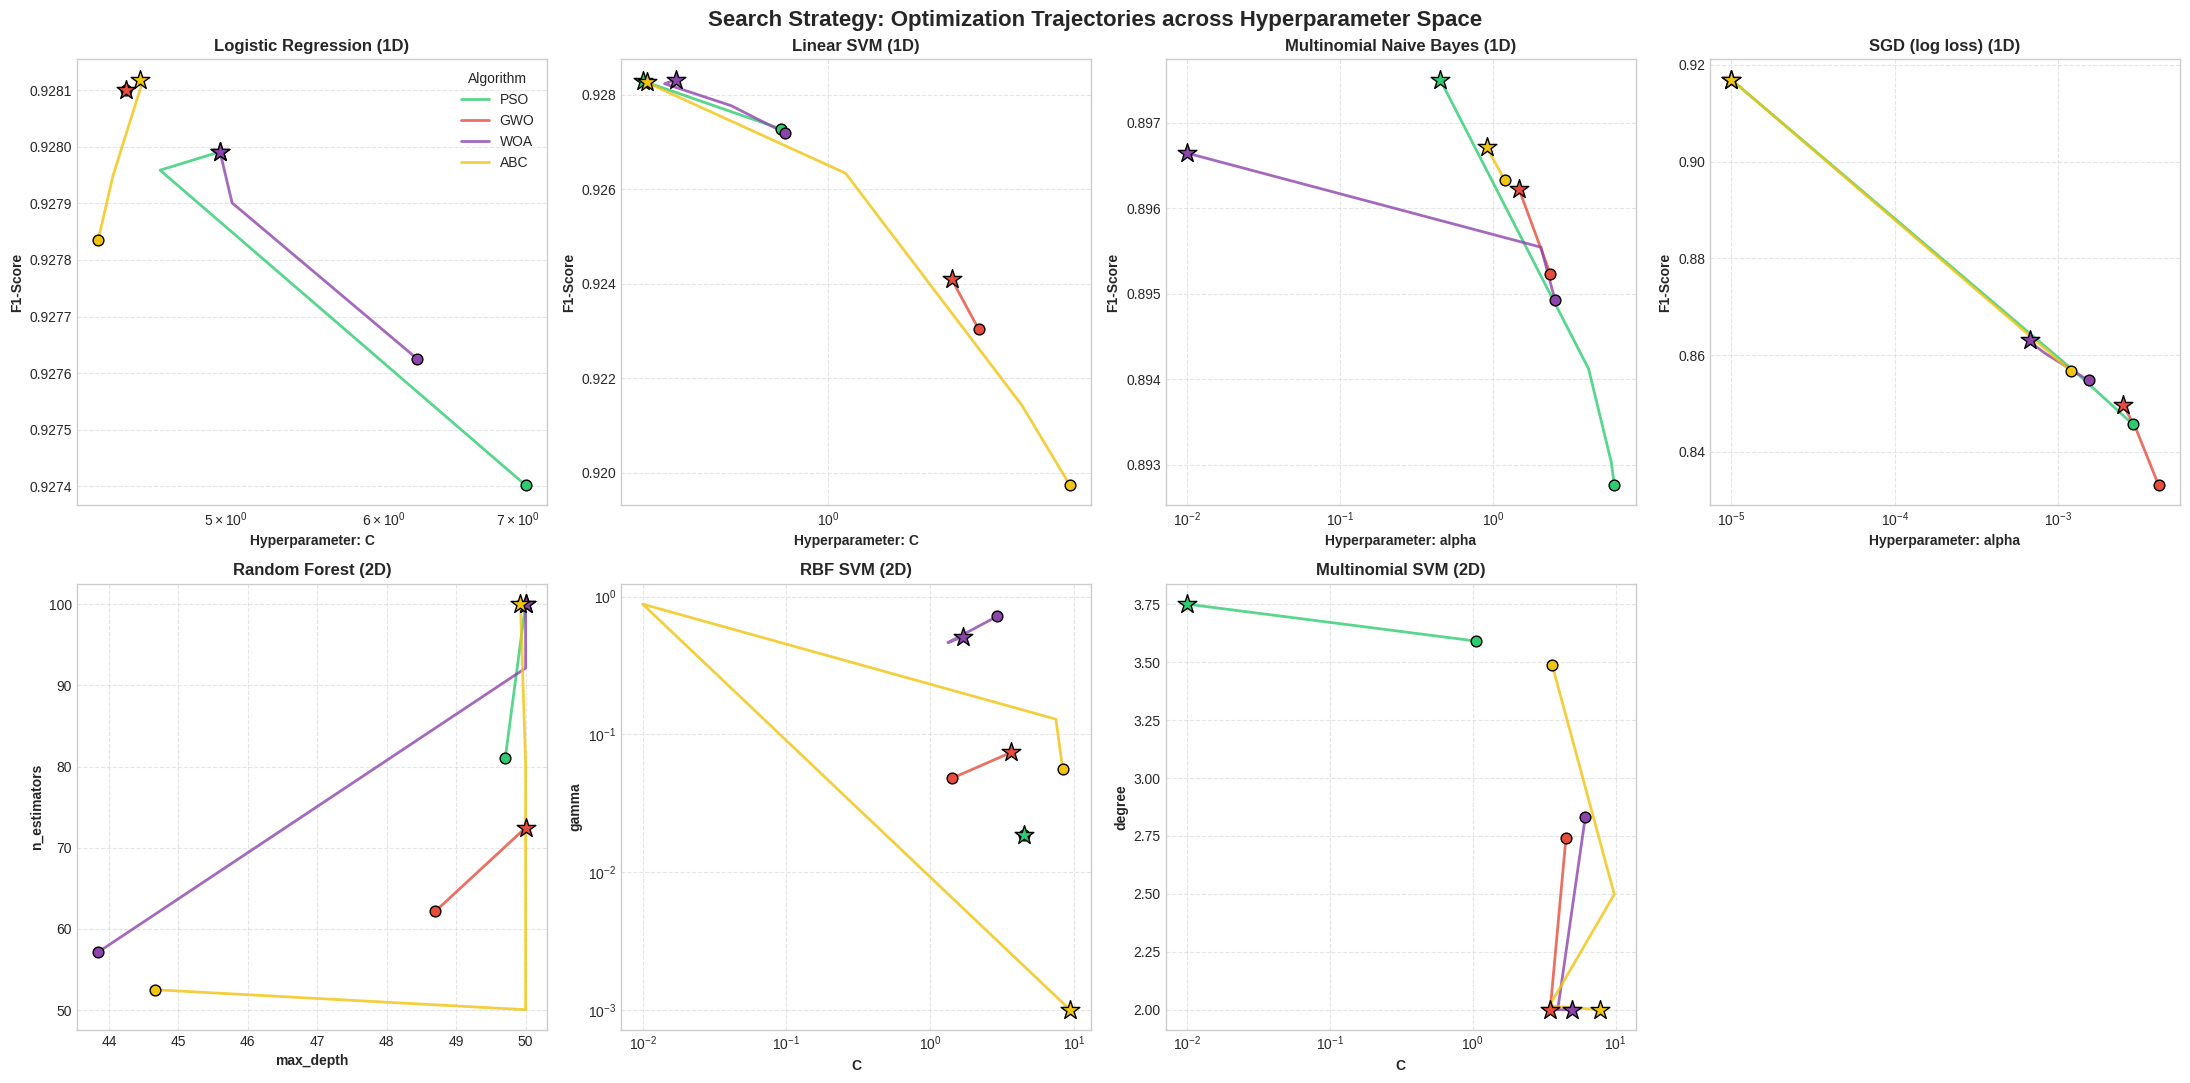

In [18]:
# --- Hyperparameter Tuning via Metaheuristics ---
from sklearn.metrics import f1_score

MODEL_BOUNDS = {
    "Logistic Regression": {
        "C": (0.01, 10.0)
    },
    "Linear SVM": {
        "C": (0.01, 10.0)
    },
    "Multinomial Naive Bayes": {
        "alpha": (0.01, 10.0)
    },
    "SGD (log loss)": {
        "alpha": (1e-5, 1e-2)
    },
    "Random Forest": {
        "max_depth": (5, 50),
        "n_estimators": (10, 100)
    },
    # "Neural Network": {
    #     "alpha": (1e-5, 1e-2),
    #     "learning_rate_init": (1e-4, 1e-2)
    # },
    "RBF SVM": {
        "C": (0.01, 10.0),
        "gamma": (0.001, 1.0)
    },
    "Multinomial SVM": {
        "C": (0.01, 10.0),
        "degree": (2, 4)
    }
}

def fit_model_with_params(model_name, params):
    """Fit and return model object for serialization/logging."""
    model = create_model(model_name, params)
    model.fit(X_train_tfidf, y_train)
    return model

def evaluate_model_params(model_name, params):
    """Fit model and return classification performance (F1-score)."""
    model = fit_model_with_params(model_name, params)
    preds = model.predict(X_test_tfidf)
    return f1_score(y_test, preds)

# 1. Particle Swarm Optimization (PSO)
def run_pso(model_name, bounds, pop_size=3, max_iter=5):
    start_time = time.time()
    keys = list(bounds.keys())
    
    particles = []
    for _ in range(pop_size):
        pos = {k: random.uniform(*bounds[k]) for k in keys}
        vel = {k: 0.0 for k in keys}
        particles.append({
            "pos": pos,
            "vel": vel,
            "best_pos": pos.copy(),
            "best_score": evaluate_model_params(model_name, pos)
        })
        
    best_global = max(particles, key=lambda x: x["best_score"])
    g_best_pos = best_global["pos"].copy()
    g_best_score = best_global["best_score"]
    
    history = [{"iter": 0, "score": g_best_score, "pos": g_best_pos.copy()}]
    
    for t in range(1, max_iter + 1):
        for p in particles:
            new_pos = {}
            for k in keys:
                r1, r2 = random.random(), random.random()
                p["vel"][k] = 0.7 * p["vel"][k] + 1.5 * r1 * (p["best_pos"][k] - p["pos"][k]) + 1.5 * r2 * (g_best_pos[k] - p["pos"][k])
                new_val = p["pos"][k] + p["vel"][k]
                new_pos[k] = max(bounds[k][0], min(new_val, bounds[k][1]))
            p["pos"] = new_pos
            score = evaluate_model_params(model_name, new_pos)
            if score > p["best_score"]:
                p["best_score"] = score
                p["best_pos"] = new_pos.copy()
            if score > g_best_score:
                g_best_score = score
                g_best_pos = new_pos.copy()
        history.append({"iter": t, "score": g_best_score, "pos": g_best_pos.copy()})
                
    return {
        "model": model_name,
        "method": "PSO",
        "accuracy": g_best_score,
        "time": time.time() - start_time,
        "best_params": g_best_pos,
        "history": history
    }

# 2. Grey Wolf Optimizer (GWO)
def run_gwo(model_name, bounds, pop_size=3, max_iter=5):
    start_time = time.time()
    keys = list(bounds.keys())
    
    wolves = [{k: random.uniform(*bounds[k]) for k in keys} for _ in range(pop_size)]
    
    alpha_pos, alpha_score = None, -np.inf
    beta_pos, beta_score = None, -np.inf
    delta_pos, delta_score = None, -np.inf
    
    for i in range(pop_size):
        score = evaluate_model_params(model_name, wolves[i])
        if score > alpha_score:
            delta_score, delta_pos = beta_score, beta_pos.copy() if beta_pos else None
            beta_score, beta_pos = alpha_score, alpha_pos.copy() if alpha_pos else None
            alpha_score, alpha_pos = score, wolves[i].copy()
        elif score > beta_score:
            delta_score, delta_pos = beta_score, beta_pos.copy() if beta_pos else None
            beta_score, beta_pos = score, wolves[i].copy()
        elif score > delta_score:
            delta_score, delta_pos = score, wolves[i].copy()
            
    history = [{"iter": 0, "score": alpha_score, "pos": alpha_pos.copy()}]
    
    for t in range(1, max_iter + 1):
        a = 2 - 2 * (t / max_iter)
        for i in range(pop_size):
            new_pos = {}
            for k in keys:
                r1, r2 = random.random(), random.random()
                A1, C1 = 2 * a * r1 - a, 2 * r2
                D_alpha = abs(C1 * alpha_pos[k] - wolves[i][k])
                X1 = alpha_pos[k] - A1 * D_alpha
                
                X2 = wolves[i][k]
                if beta_pos:
                    r1, r2 = random.random(), random.random()
                    A2, C2 = 2 * a * r1 - a, 2 * r2
                    D_beta = abs(C2 * beta_pos[k] - wolves[i][k])
                    X2 = beta_pos[k] - A2 * D_beta
                    
                X3 = wolves[i][k]
                if delta_pos:
                    r1, r2 = random.random(), random.random()
                    A3, C3 = 2 * a * r1 - a, 2 * r2
                    D_delta = abs(C3 * delta_pos[k] - wolves[i][k])
                    X3 = delta_pos[k] - A3 * D_delta
                    
                new_val = (X1 + X2 + X3) / 3
                new_pos[k] = max(bounds[k][0], min(new_val, bounds[k][1]))
            wolves[i] = new_pos
            
        for i in range(pop_size):
            score = evaluate_model_params(model_name, wolves[i])
            if score > alpha_score:
                delta_score, delta_pos = beta_score, beta_pos.copy() if beta_pos else None
                beta_score, beta_pos = alpha_score, alpha_pos.copy() if alpha_pos else None
                alpha_score, alpha_pos = score, wolves[i].copy()
            elif score > beta_score:
                delta_score, delta_pos = beta_score, beta_pos.copy() if beta_pos else None
                beta_score, beta_pos = score, wolves[i].copy()
            elif score > delta_score:
                delta_score, delta_pos = score, wolves[i].copy()
                
        history.append({"iter": t, "score": alpha_score, "pos": alpha_pos.copy()})
            
    return {
        "model": model_name,
        "method": "GWO",
        "accuracy": alpha_score,
        "time": time.time() - start_time,
        "best_params": alpha_pos,
        "history": history
    }

# 3. Whale Optimization Algorithm (WOA)
def run_woa(model_name, bounds, pop_size=3, max_iter=5, b=1.0):
    start_time = time.time()
    keys = list(bounds.keys())
    
    whales = [{k: random.uniform(*bounds[k]) for k in keys} for _ in range(pop_size)]
    scores = [evaluate_model_params(model_name, w) for w in whales]
    
    best_whale = whales[np.argmax(scores)].copy()
    best_score = np.max(scores)
    
    history = [{"iter": 0, "score": best_score, "pos": best_whale.copy()}]
    
    for t in range(1, max_iter + 1):
        a = 2 - 2 * (t / max_iter)
        for i in range(pop_size):
            A = 2 * a * random.random() - a
            C = 2 * random.random()
            p, l = random.random(), random.uniform(-1, 1)
            
            new_pos = {}
            for k in keys:
                if p >= 0.5:
                    dist = abs(best_whale[k] - whales[i][k])
                    new_val = dist * np.exp(b * l) * np.cos(2 * np.pi * l) + best_whale[k]
                else:
                    if abs(A) < 1:
                        new_val = best_whale[k] - A * abs(C * best_whale[k] - whales[i][k])
                    else:
                        rand_w = random.choice(whales)
                        new_val = rand_w[k] - A * abs(C * rand_w[k] - whales[i][k])
                new_pos[k] = max(bounds[k][0], min(new_val, bounds[k][1]))
                
            score = evaluate_model_params(model_name, new_pos)
            if score >= scores[i]:
                whales[i] = new_pos.copy()
                scores[i] = score
                if score > best_score:
                    best_score = score
                    best_whale = new_pos.copy()
        history.append({"iter": t, "score": best_score, "pos": best_whale.copy()})
                    
    return {
        "model": model_name,
        "method": "WOA",
        "accuracy": best_score,
        "time": time.time() - start_time,
        "best_params": best_whale,
        "history": history
    }

# 4. Artificial Bee Colony (ABC)
def run_abc(model_name, bounds, pop_size=3, max_iter=5, limit=2):
    start_time = time.time()
    keys = list(bounds.keys())
    
    food_sources = [{k: random.uniform(*bounds[k]) for k in keys} for _ in range(pop_size)]
    scores = [evaluate_model_params(model_name, fs) for fs in food_sources]
    trial_counters = [0] * pop_size
    
    best_pos = food_sources[np.argmax(scores)].copy()
    best_score = np.max(scores)
    
    history = [{"iter": 0, "score": best_score, "pos": best_pos.copy()}]
    
    for t in range(1, max_iter + 1):
        for i in range(pop_size):
            k = np.random.choice([idx for idx in range(pop_size) if idx != i]) if pop_size > 1 else i
            new_pos = {}
            for param in keys:
                phi = random.uniform(-1, 1)
                new_val = food_sources[i][param] + phi * (food_sources[i][param] - food_sources[k][param])
                new_pos[param] = max(bounds[param][0], min(new_val, bounds[param][1]))
            score = evaluate_model_params(model_name, new_pos)
            if score > scores[i]:
                food_sources[i] = new_pos.copy()
                scores[i] = score
                trial_counters[i] = 0
            else:
                trial_counters[i] += 1
                
        fit_shifted = np.array(scores) - np.min(scores) + 1e-6
        probs = fit_shifted / np.sum(fit_shifted)
        for _ in range(pop_size):
            i = np.random.choice(range(pop_size), p=probs)
            k = np.random.choice([idx for idx in range(pop_size) if idx != i]) if pop_size > 1 else i
            new_pos = {}
            for param in keys:
                phi = random.uniform(-1, 1)
                new_val = food_sources[i][param] + phi * (food_sources[i][param] - food_sources[k][param])
                new_pos[param] = max(bounds[param][0], min(new_val, bounds[param][1]))
            score = evaluate_model_params(model_name, new_pos)
            if score > scores[i]:
                food_sources[i] = new_pos.copy()
                scores[i] = score
                trial_counters[i] = 0
            else:
                trial_counters[i] += 1
        for i in range(pop_size):
            if trial_counters[i] > limit:
                food_sources[i] = {param: random.uniform(*bounds[param]) for param in keys}
                scores[i] = evaluate_model_params(model_name, food_sources[i])
                trial_counters[i] = 0
        curr_best_idx = np.argmax(scores)
        if scores[curr_best_idx] > best_score:
            best_score = scores[curr_best_idx]
            best_pos = food_sources[curr_best_idx].copy()
        history.append({"iter": t, "score": best_score, "pos": best_pos.copy()})
            
    return {
        "model": model_name,
        "method": "ABC",
        "accuracy": best_score,
        "time": time.time() - start_time,
        "best_params": best_pos,
        "history": history
    }

# Execute Tuning
tuning_results = []
for model_name, bounds in MODEL_BOUNDS.items():
    print(f"\nTuning hyperparameters for {model_name}...")
    for algo_name, algo_func in [("PSO", run_pso), ("GWO", run_gwo), ("WOA", run_woa), ("ABC", run_abc)]:
        print(f"  Running {algo_name}...")
        res = algo_func(model_name, bounds, pop_size=3, max_iter=5)
        tuning_results.append(res)
        
        # Log to MLflow
        try:
            if mlflow.active_run():
                mlflow.end_run()
            with mlflow.start_run(run_name=f"{model_name} - {algo_name} Tuning"):
                mlflow.log_param("model_name", model_name)
                mlflow.log_param("tuning_algorithm", algo_name)
                mlflow.log_param("seed", RANDOM_SEED)
                for param_name, param_val in res["best_params"].items():
                    mlflow.log_param(f"best_{param_name}", param_val)
                for param_name, param_range in bounds.items():
                    mlflow.log_param(f"bound_{param_name}", str(param_range))
                mlflow.log_metric("f1_score", res["accuracy"])
                mlflow.log_metric("tuning_time_sec", res["time"])
                
                # Fit and log the best model artifact
                best_model_obj = fit_model_with_params(model_name, res["best_params"])
                try:
                    mlflow.sklearn.log_model(best_model_obj, "model")
                    print(f"  Successfully logged {model_name} - {algo_name} and its model artifact to MLflow.")
                except Exception as me:
                    print(f"  Warning: Failed to log model artifact: {me}")
        except Exception as e:
            print(f"  Warning: Failed to log to MLflow: {e}")

tuning_df = pd.DataFrame(tuning_results)
print("\nHyperparameter Tuning Results:")
print(tuning_df[["model", "method", "accuracy", "time", "best_params"]].to_string(index=False))

# --- Visualization 1: Tuning Efficiency & Dual-Axis Ranking (Index 57 Style) ---
plt.style.use('seaborn-v0_8-whitegrid')
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 6.5))

colors = {"PSO": "#2ecc71", "GWO": "#e74c3c", "WOA": "#8e44ad", "ABC": "#f1c40f"}
for name, group in tuning_df.groupby("method"):
    ax1.scatter(group["time"], group["accuracy"], label=name, s=250, color=colors[name], edgecolors='black', alpha=0.85, zorder=3)
ax1.set_xlabel("Tuning Time (seconds)", fontsize=11, fontweight='bold')
ax1.set_ylabel("Best F1-Score Found", fontsize=11, fontweight='bold')
ax1.set_title("Efficiency Frontier: Tuning Time vs. F1-Score", fontsize=13, fontweight='bold')
ax1.legend(loc='lower right', frameon=True)
ax1.grid(True, linestyle='--', alpha=0.5)

sns.barplot(data=tuning_df, x="model", y="accuracy", hue="method", ax=ax2, palette='Blues_d', alpha=0.8)
ax2.set_ylabel("Best F1-Score", fontsize=11, fontweight='bold')
ax2.set_xlabel("")
ax2.set_title("Algorithm Performance Ranking vs. Cost (Execution Time)", fontsize=13, fontweight='bold')
ax2.set_xticklabels(ax2.get_xticklabels(), rotation=15, ha='right')

ax_time = ax2.twinx()
mean_times = tuning_df.groupby("model")["time"].mean().reindex(tuning_df["model"].unique())
sns.lineplot(x=mean_times.index, y=mean_times.values, ax=ax_time, color='crimson', marker='o', lw=2.5, markersize=8, label='Mean Time (s)')
ax_time.set_ylabel("Mean Execution Time (s)", color='crimson', fontsize=11, fontweight='bold')
ax_time.tick_params(axis='y', labelcolor='crimson')
ax2.set_ylim(tuning_df["accuracy"].min() - 0.02, tuning_df["accuracy"].max() + 0.01)

plt.tight_layout()
plt.show()

# --- Visualization 2: Convergence Curves (Index 58 Style) ---
n_models = len(MODEL_BOUNDS)
fig, axes = plt.subplots(2, 4, figsize=(18, 11), sharey=True)
axes = axes.flatten()

for idx, (model_name, ax) in enumerate(zip(MODEL_BOUNDS.keys(), axes)):
    model_df = tuning_df[tuning_df["model"] == model_name]
    for _, row in model_df.iterrows():
        method_name = row["method"]
        scores = [h["score"] for h in row["history"]]
        ax.plot(scores, marker='o', label=method_name, color=colors[method_name], linewidth=2.5, alpha=0.8)
    
    ax.set_title(f"{model_name}", fontsize=12, fontweight='bold')
    ax.set_xlabel("Iteration", fontsize=10)
    if idx % 4 == 0:
        ax.set_ylabel("F1-Score", fontsize=11, fontweight='bold')
    ax.set_xticks(range(6))
    ax.grid(True, linestyle='--', alpha=0.5)
    if idx == n_models - 1:
        ax.legend(title="Algorithm", loc="lower right")

# Remove any unused subplot axes
for i in range(n_models, len(axes)):
    fig.delaxes(axes[i])

plt.suptitle("Convergence Speed: F1-Score Learning Curves across Metaheuristics", fontsize=15, fontweight='bold', y=0.98)
plt.tight_layout()
plt.show()

# --- Visualization 3: Search Trajectories on Hyperparameter Space (All 8 Models) ---
fig, axes = plt.subplots(2, 4, figsize=(22, 11))
axes = axes.flatten()

for idx, (model_name, bounds) in enumerate(MODEL_BOUNDS.items()):
    ax = axes[idx]
    model_df = tuning_df[tuning_df["model"] == model_name]
    params = list(bounds.keys())
    
    if len(params) == 1:
        # 1D Parameter Search Space: Plot parameter value vs. F1-score
        param_name = params[0]
        for _, row in model_df.iterrows():
            method_name = row["method"]
            history = row["history"]
            
            param_vals = [h["pos"][param_name] for h in history]
            scores = [h["score"] for h in history]
            
            # Plot path
            ax.plot(param_vals, scores, linestyle='-', marker='', color=colors[method_name], label=method_name, alpha=0.8, linewidth=2.0)
            # Plot Start (circle) and End/Best (star)
            ax.scatter(param_vals[0], scores[0], s=60, color=colors[method_name], marker='o', edgecolors='black', zorder=5)
            ax.scatter(param_vals[-1], scores[-1], s=200, color=colors[method_name], marker='*', edgecolors='black', zorder=5)
            
        ax.set_xlabel(f"Hyperparameter: {param_name}", fontsize=10, fontweight='bold')
        ax.set_ylabel("F1-Score", fontsize=10, fontweight='bold')
        ax.set_title(f"{model_name} (1D)", fontsize=12, fontweight='bold')
        
        # Apply log scale if bounds span at least 100x
        if bounds[param_name][0] > 0 and (bounds[param_name][1] / bounds[param_name][0]) >= 100:
            ax.set_xscale('log')
            
    elif len(params) == 2:
        # 2D Parameter Search Space: Plot Parameter 1 vs. Parameter 2
        param1, param2 = params[0], params[1]
        for _, row in model_df.iterrows():
            method_name = row["method"]
            history = row["history"]
            
            p1_vals = [h["pos"][param1] for h in history]
            p2_vals = [h["pos"][param2] for h in history]
            
            # Plot path
            ax.plot(p1_vals, p2_vals, linestyle='-', marker='', color=colors[method_name], label=method_name, alpha=0.8, linewidth=2.0)
            # Plot Start (circle) and End/Best (star)
            ax.scatter(p1_vals[0], p2_vals[0], s=60, color=colors[method_name], marker='o', edgecolors='black', zorder=5)
            ax.scatter(p1_vals[-1], p2_vals[-1], s=200, color=colors[method_name], marker='*', edgecolors='black', zorder=5)
            
        ax.set_xlabel(f"{param1}", fontsize=10, fontweight='bold')
        ax.set_ylabel(f"{param2}", fontsize=10, fontweight='bold')
        ax.set_title(f"{model_name} (2D)", fontsize=12, fontweight='bold')
        
        # Apply log scale to axes if bounds span at least 100x
        if bounds[param1][0] > 0 and (bounds[param1][1] / bounds[param1][0]) >= 100:
            ax.set_xscale('log')
        if bounds[param2][0] > 0 and (bounds[param2][1] / bounds[param2][0]) >= 100:
            ax.set_yscale('log')
            
    ax.grid(True, linestyle='--', alpha=0.5)
    if idx == 0:
        ax.legend(title="Algorithm", loc="best")

# Remove any unused subplot axes
for i in range(n_models, len(axes)):
    fig.delaxes(axes[i])

plt.suptitle("Search Strategy: Optimization Trajectories across Hyperparameter Space", fontsize=16, fontweight='bold', y=0.98)
plt.tight_layout()
plt.show()


## 13.8. Model Explainability: Interpreting Classifier Decisions (XAI)

To understand how the models arrive at their decisions, we implement three levels of explainability:
1. **Direct Feature Coefficients (Global Interpretation):** Mapping model weights directly to words.
2. **LIME (Local Interpretation):** Perturbing word tokens locally to explain individual predictions.
3. **SHAP (Game-Theoretic Local Interpretation):** Computing exact Shapley values to measure additive token contributions.

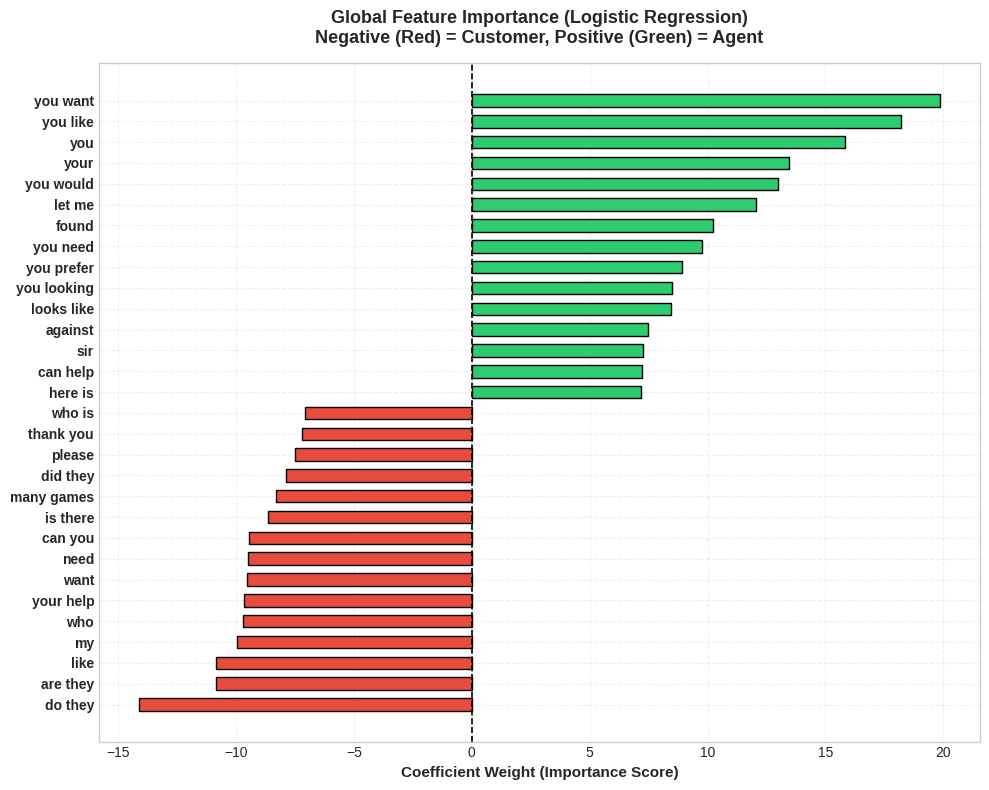

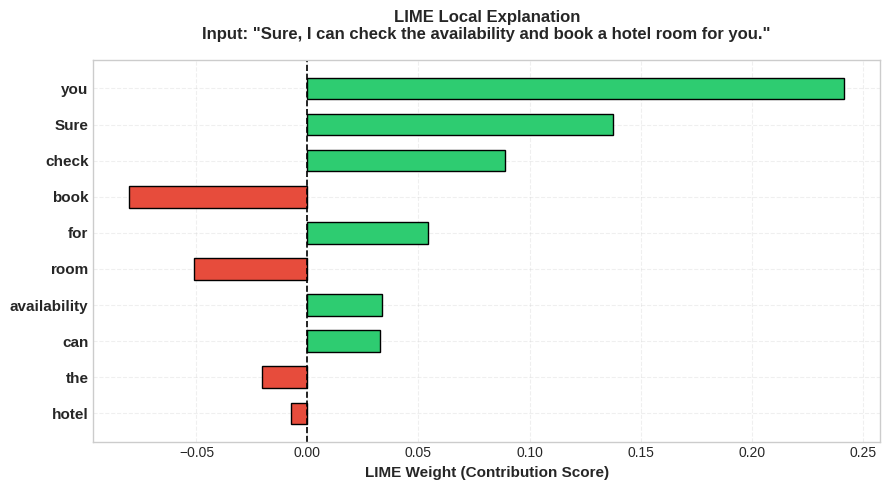

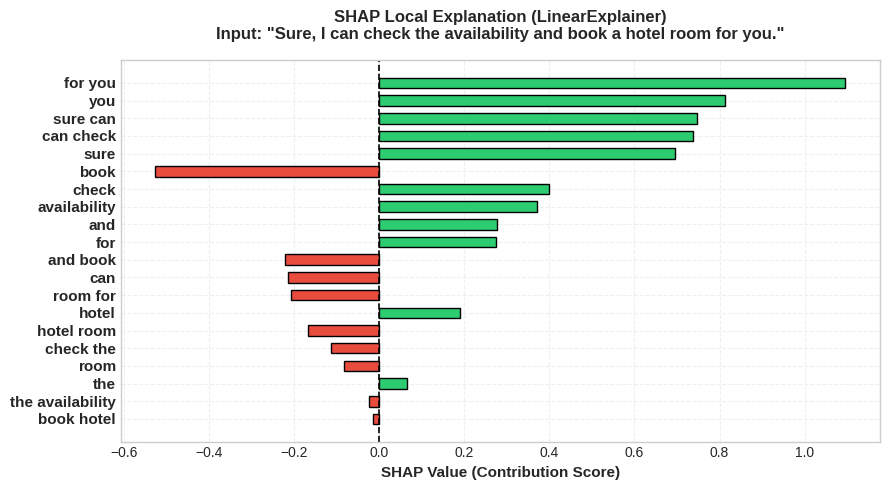

In [19]:
# --- Explainability (XAI) ---
from sklearn.pipeline import make_pipeline
from lime.lime_text import LimeTextExplainer
import shap

# Set style
plt.style.use('seaborn-v0_8-whitegrid')

# 1. Direct Coefficient Visualization (Logistic Regression)
model_name = "Logistic Regression"
model = trained[model_name]
coefs = model.coef_[0]
vocab = vectorizer.get_feature_names_out()

# Get top 15 positive (agent) and negative (customer) features
top_positive_indices = np.argsort(coefs)[-15:]
top_negative_indices = np.argsort(coefs)[:15]

top_indices = np.concatenate([top_negative_indices, top_positive_indices])
top_coefs = coefs[top_indices]
top_words = vocab[top_indices]

fig, ax = plt.subplots(figsize=(10, 8), facecolor='white')
colors = ["#e74c3c" if c < 0 else "#2ecc71" for c in top_coefs]

ax.barh(range(len(top_coefs)), top_coefs, color=colors, edgecolor='black', height=0.6)
ax.set_yticks(range(len(top_coefs)))
ax.set_yticklabels(top_words, fontsize=10, fontweight='bold')
ax.axvline(0, color='black', linestyle='--', linewidth=1.2)
ax.set_xlabel("Coefficient Weight (Importance Score)", fontsize=11, fontweight='bold')
ax.set_title("Global Feature Importance (Logistic Regression)\nNegative (Red) = Customer, Positive (Green) = Agent", fontsize=13, fontweight='bold', pad=15)
ax.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

# 2. LIME Local Explanation
explainer = LimeTextExplainer(class_names=["customer", "agent"])
text_to_explain = "Sure, I can check the availability and book a hotel room for you."
pipeline = make_pipeline(vectorizer, model)
exp = explainer.explain_instance(text_to_explain, pipeline.predict_proba, num_features=10)

lime_list = exp.as_list()
words = [x[0] for x in lime_list]
weights = [x[1] for x in lime_list]

fig, ax = plt.subplots(figsize=(9, 5), facecolor='white')
colors = ["#2ecc71" if w > 0 else "#e74c3c" for w in weights]
y_pos = range(len(words))
ax.barh(y_pos, weights, color=colors, edgecolor='black', height=0.6)
ax.set_yticks(y_pos)
ax.set_yticklabels(words, fontsize=11, fontweight='bold')
ax.axvline(0, color='black', linestyle='--', linewidth=1.2)
ax.set_xlabel("LIME Weight (Contribution Score)", fontsize=11, fontweight='bold')
ax.set_title(f"LIME Local Explanation\nInput: \"{text_to_explain}\"", fontsize=12, fontweight='bold', pad=15)
ax.invert_yaxis()
ax.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

# 3. SHAP Local Explanation (LinearExplainer)
shap_explainer = shap.LinearExplainer(model, X_test_tfidf)
instance_vec = vectorizer.transform([text_to_explain]).toarray()[0]
shap_values = shap_explainer.shap_values(instance_vec)

non_zero_indices = np.where(instance_vec > 0)[0]
non_zero_shap = shap_values[non_zero_indices]
non_zero_words = vocab[non_zero_indices]

sort_order = np.argsort(np.abs(non_zero_shap))[::-1]
non_zero_shap = non_zero_shap[sort_order]
non_zero_words = non_zero_words[sort_order]

fig, ax = plt.subplots(figsize=(9, 5), facecolor='white')
colors = ["#2ecc71" if val > 0 else "#e74c3c" for val in non_zero_shap]
y_pos = range(len(non_zero_shap))
ax.barh(y_pos, non_zero_shap, color=colors, edgecolor='black', height=0.6)
ax.set_yticks(y_pos)
ax.set_yticklabels(non_zero_words, fontsize=11, fontweight='bold')
ax.axvline(0, color='black', linestyle='--', linewidth=1.2)
ax.set_xlabel("SHAP Value (Contribution Score)", fontsize=11, fontweight='bold')
ax.set_title(f"SHAP Local Explanation (LinearExplainer)\nInput: \"{text_to_explain}\"", fontsize=12, fontweight='bold', pad=15)
ax.invert_yaxis()
ax.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()


## 14. Conclusion

- The dataset combines every `USER` (customer) and `ASSISTANT` (agent)
  utterance from **TM-1** and **TM-2** Taskmaster dialogues (~400K clean rows
  after deduplication).
- TF-IDF (uni- and bi-grams) features were used to train five classical
  models; the bar chart, confusion matrices and ROC curves above compare them
  on the held-out test set.
- The hand-written sanity check and error analysis confirm the best model
  (highest F1) generalizes the *agent vs. customer* concept beyond the
  training distribution, while also showing the kinds of short/ambiguous
  utterances that remain hard to classify.

To improve further, consider: contextual features (previous utterance,
position in dialogue), character n-grams, or fine-tuning a transformer
(e.g. DistilBERT) for sequence classification.


## 15. Download Best Logistic Regression Model from MLflow

Based on the training and evaluation results, the best baseline model is **Logistic Regression (Word TF-IDF)** (Run ID: `85c2377290ee459a8232c8136d0721c5`) with F1 score: `0.9245`.  
Below is the code to download this model directly from the DagsHub MLflow tracking server using pre-emptive Basic Auth. It includes both a dynamic query-based search method and a static fallback using the verified direct download URL of the best run.

In [ ]:
import os
import base64
import urllib.request
import json
import yaml

# 1. Configure MLflow tracking server connection credentials
os.environ["MLFLOW_TRACKING_URI"] = "https://dagshub.com/jalalqassas/vocalMind.mlflow"
os.environ["MLFLOW_TRACKING_USERNAME"] = "jalalqassas"
os.environ["MLFLOW_TRACKING_PASSWORD"] = "56fa62fc8fb1ef39d3c67021e2da18c8cb521100"

owner = "jalalqassas"
repo = "vocalMind"
experiment_hash = "6bf7a93fa47a46e6af8a23e94fcb613c"

auth_str = f"{os.environ['MLFLOW_TRACKING_USERNAME']}:{os.environ['MLFLOW_TRACKING_PASSWORD']}"
b64_auth = base64.b64encode(auth_str.encode("utf-8")).decode("utf-8")

def download_file(path, dest):
    url = f"https://dagshub.com/{owner}/{repo}.mlflow/api/2.0/mlflow-artifacts/artifacts/{path}"
    print(f"Downloading from: {url}")
    req = urllib.request.Request(url)
    req.add_header("Authorization", f"Basic {b64_auth}")
    with urllib.request.urlopen(req) as response:
        content = response.read()
        with open(dest, "wb") as f:
            f.write(content)
        print(f"Successfully downloaded {dest} ({len(content)} bytes)")
        return True

# --- Method 1: Dynamic Remote Search on DagsHub MLflow ---
try:
    print("--- Method 1: Dynamic Remote Search ---")
    import mlflow
    mlflow.set_tracking_uri(os.environ["MLFLOW_TRACKING_URI"])
    client = mlflow.tracking.MlflowClient()
    
    # Query only Logistic Regression runs using server-side filtering (extremely fast)
    runs = client.search_runs(
        experiment_ids=["0"],
        filter_string="tags.mlflow.runName LIKE 'Logistic Regression%'"
    )
    runs_sorted = sorted(
        runs,
        key=lambda r: r.data.metrics.get("f1", r.data.metrics.get("f1_score", 0)),
        reverse=True
    )
    
    # List model directories in storage
    list_url = f"https://dagshub.com/{owner}/{repo}.mlflow/api/2.0/mlflow-artifacts/artifacts?path={experiment_hash}/models"
    req_list = urllib.request.Request(list_url)
    req_list.add_header("Authorization", f"Basic {b64_auth}")
    with urllib.request.urlopen(req_list) as response:
        model_dirs = json.loads(response.read().decode("utf-8")).get("files", [])
        
    # Build run_id -> model_dir mapping
    run_to_model_dir = {}
    for m in model_dirs:
        m_name = m["path"]
        mlmodel_url = f"https://dagshub.com/{owner}/{repo}.mlflow/api/2.0/mlflow-artifacts/artifacts/{experiment_hash}/models/{m_name}/artifacts/MLmodel"
        req_meta = urllib.request.Request(mlmodel_url)
        req_meta.add_header("Authorization", f"Basic {b64_auth}")
        try:
            with urllib.request.urlopen(req_meta, timeout=5) as resp_meta:
                meta = yaml.safe_load(resp_meta.read().decode("utf-8"))
                run_id = meta.get("run_id")
                if run_id:
                    run_to_model_dir[run_id] = m_name
        except Exception:
            pass
            
    # Find the best run with artifacts
    best_run = None
    best_model_dir = None
    for r in runs_sorted:
        r_id = r.info.run_id
        if r_id in run_to_model_dir:
            best_run = r
            best_model_dir = run_to_model_dir[r_id]
            break
            
    if not best_run:
        raise ValueError("No run with artifacts found in storage.")
        
    best_run_id = best_run.info.run_id
    model_artifact_path = f"{experiment_hash}/models/{best_model_dir}/artifacts/model.pkl"
    download_file(model_artifact_path, "model.pkl")
    print("Method 1 succeeded!")
except Exception as e:
    print(f"Method 1 failed or timed out: {e}")
    
    # --- Method 2: Fallback direct download using verified static path ---
    print("\n--- Method 2: Verified Static Fallback ---")
    # Best run: 85c2377290ee459a8232c8136d0721c5 -> model dir: m-1adecb2eee78474fab12f7a8d7b20417
    static_run_id = "85c2377290ee459a8232c8136d0721c5"
    static_model_dir = "m-1adecb2eee78474fab12f7a8d7b20417"
    static_path = f"{experiment_hash}/models/{static_model_dir}/artifacts/model.pkl"
    try:
        download_file(static_path, "model.pkl")
        print("Method 2 succeeded!")
    except Exception as ex:
        print(f"Method 2 failed: {ex}")

# --- Save Local Vectorizer ---
try:
    import joblib
    if 'vectorizer' in globals():
        joblib.dump(vectorizer, "vectorizer.pkl")
        print("Successfully saved local vectorizer to vectorizer.pkl")
    else:
        print("Warning: 'vectorizer' object not found in notebook namespace; skipping local dump.")
except Exception as e:
    print(f"Failed to save local vectorizer: {e}")
